In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

I0000 00:00:1777388060.200298  220628 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777388062.040045  220628 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
file_path = "/home/home/code/xucenying/grid-intelligence/notebooks/susanta/consolidated_full.csv"
df=pd.read_csv(file_path)


In [3]:
df.shape

(265541, 26)

In [4]:
df.isnull().sum()

datetime_utc                             0
generation                             342
consumption                            359
wind_onshore                           343
temperature_c                        87896
humidity_percent                     87896
cloud_cover_percent                  87900
shortwave_radiation_wm2              87900
wind_speed_ms                        87896
ttf_gas                               6522
price                                  393
generation_renewable                   342
generation_non_renewable               342
wti_oil                                437
brent_oil                              437
natural_gas                            437
temperature_c_observed                 371
humidity_percent_observed              371
cloud_cover_percent_observed           371
shortwave_radiation_wm2_observed       371
wind_speed_ms_observed                 371
temperature_c_forecast              265178
humidity_percent_forecast           265178
cloud_cover

In [5]:
df.keys()

Index(['datetime_utc', 'generation', 'consumption', 'wind_onshore',
       'temperature_c', 'humidity_percent', 'cloud_cover_percent',
       'shortwave_radiation_wm2', 'wind_speed_ms', 'ttf_gas', 'price',
       'generation_renewable', 'generation_non_renewable', 'wti_oil',
       'brent_oil', 'natural_gas', 'temperature_c_observed',
       'humidity_percent_observed', 'cloud_cover_percent_observed',
       'shortwave_radiation_wm2_observed', 'wind_speed_ms_observed',
       'temperature_c_forecast', 'humidity_percent_forecast',
       'cloud_cover_percent_forecast', 'shortwave_radiation_wm2_forecast',
       'wind_speed_ms_forecast'],
      dtype='object')

In [6]:
data = df.drop(columns = ['temperature_c', 'humidity_percent', 'cloud_cover_percent',
       'shortwave_radiation_wm2', 'wind_speed_ms', 'temperature_c_forecast', 'humidity_percent_forecast',
       'cloud_cover_percent_forecast', 'shortwave_radiation_wm2_forecast',
       'wind_speed_ms_forecast'])

In [7]:
data.head(5)

,datetime_utc,generation,consumption,wind_onshore,ttf_gas,price,generation_renewable,generation_non_renewable,wti_oil,brent_oil,natural_gas,temperature_c_observed,humidity_percent_observed,cloud_cover_percent_observed,shortwave_radiation_wm2_observed,wind_speed_ms_observed
0,2018-09-30 22:00:00+00:00,51434.81,NaN,4292.89,NaN,49.30,11863.35,28945.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-09-30 22:15:00+00:00,52085.57,NaN,4239.07,NaN,44.38,11809.11,29001.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-09-30 22:30:00+00:00,52345.33,NaN,4208.44,NaN,36.99,11632.71,29136.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-09-30 22:45:00+00:00,52902.03,NaN,4153.52,NaN,35.54,11937.48,28929.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-09-30 23:00:00+00:00,52799.83,42354.46,4047.26,NaN,46.50,12005.45,28880.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
data.isnull().sum()

datetime_utc                           0
generation                           342
consumption                          359
wind_onshore                         343
ttf_gas                             6522
price                                393
generation_renewable                 342
generation_non_renewable             342
wti_oil                              437
brent_oil                            437
natural_gas                          437
temperature_c_observed               371
humidity_percent_observed            371
cloud_cover_percent_observed         371
shortwave_radiation_wm2_observed     371
wind_speed_ms_observed               371
dtype: int64

In [9]:
data.keys()

Index(['datetime_utc', 'generation', 'consumption', 'wind_onshore', 'ttf_gas',
       'price', 'generation_renewable', 'generation_non_renewable', 'wti_oil',
       'brent_oil', 'natural_gas', 'temperature_c_observed',
       'humidity_percent_observed', 'cloud_cover_percent_observed',
       'shortwave_radiation_wm2_observed', 'wind_speed_ms_observed'],
      dtype='object')

 # ***Selecting data only from last one year***

In [10]:
data["datetime_utc"] = pd.to_datetime(data["datetime_utc"], utc=True)

start_date = pd.Timestamp("2025-02-01 00:00:00", tz="UTC")
end_date = pd.Timestamp("2026-02-01 00:00:00", tz="UTC")

data = data[
    (data["datetime_utc"] >= start_date) &
    (data["datetime_utc"] <= end_date)
]

In [11]:
data.tail()

,datetime_utc,generation,consumption,wind_onshore,ttf_gas,price,generation_renewable,generation_non_renewable,wti_oil,brent_oil,natural_gas,temperature_c_observed,humidity_percent_observed,cloud_cover_percent_observed,shortwave_radiation_wm2_observed,wind_speed_ms_observed
257284,2026-01-31 23:00:00+00:00,55732.36233,51641.31842,14644.42952,39.285,110.19,26734.05528,28722.69065,65.209999,70.690002,4.354,-2.400,97.079660,100.0,0.0,9.906544
257285,2026-01-31 23:15:00+00:00,55150.03397,50830.25718,14331.58355,39.285,95.14,26608.13671,28119.43306,65.209999,70.690002,4.354,-2.525,96.717320,100.0,0.0,9.199272
257286,2026-01-31 23:30:00+00:00,54411.85230,50287.21018,14160.32318,39.285,104.76,26335.74264,27619.46746,65.209999,70.690002,4.354,-2.650,96.354996,100.0,0.0,8.492001
257287,2026-01-31 23:45:00+00:00,54086.24809,49758.64134,13969.78983,39.285,95.89,26146.36708,27237.10131,65.209999,70.690002,4.354,-2.775,95.992660,100.0,0.0,7.784729
257288,2026-02-01 00:00:00+00:00,53869.80352,49125.44241,13968.65700,39.285,100.20,26089.38712,27100.08260,65.209999,70.690002,4.354,-2.900,95.630325,100.0,0.0,7.077457


# Preprocessing and cleaning #


1. Market data → step-like → ffill
2. Weather → smooth physics → interpolation
3. Observed weather → high-trust → preserve with ffill
4. Generation/consumption → continuous signals → interpolate
5. Solar → respects day/night physics
6. Target (price) → never fabricate

In [12]:
# Ensuring datetime as index
data['datetime_utc'] = pd.to_datetime(data['datetime_utc'])
data = data.set_index('datetime_utc').sort_index()

# -----------------------------
# 1. Defining column groups
# -----------------------------
weather_cols = [
    'temperature_c_observed', 'humidity_percent_observed',
    'cloud_cover_percent_observed',
    'shortwave_radiation_wm2_observed', 'wind_speed_ms_observed'
]

market_cols = [
    'ttf_gas', 'wti_oil', 'brent_oil', 'natural_gas'
]

core_cols = ['generation', 'consumption']
mix_cols = ['generation_renewable', 'generation_non_renewable']

# -----------------------------
# 2. Market variables → forward fill
# -----------------------------
data[market_cols] = data[market_cols].ffill()

# -----------------------------
# 3. Weather variables → time interpolation
# -----------------------------
data[weather_cols] = data[weather_cols].ffill().interpolate(method='time')

# -----------------------------
# 4. Core system variables → interpolate + ffill
# -----------------------------
data[core_cols] = data[core_cols].interpolate().ffill()

# -----------------------------
# 5. Energy mix → interpolate
# -----------------------------
data[mix_cols] = data[mix_cols].interpolate()

# -----------------------------
# 6. Wind generation → interpolate + light smoothing
# -----------------------------
data['wind_onshore'] = (
    data['wind_onshore']
    .interpolate()
    .rolling(3, min_periods=1)
    .mean()
)

# -----------------------------
# 7. Solar radiation (physics-aware)
# -----------------------------
# Nighttime → 0
night_mask = (data.index.hour < 6) | (data.index.hour > 20)
data.loc[night_mask, 'shortwave_radiation_wm2_observed'] = \
    data.loc[night_mask, 'shortwave_radiation_wm2_observed'].fillna(0)

# Daytime → interpolate
data['shortwave_radiation_wm2_observed'] = data['shortwave_radiation_wm2_observed'].interpolate()

# -----------------------------
# 8. Target variable →  NOT IMPUTING ANY VALUES
# -----------------------------
data = data[data['price'].notna()]

# -----------------------------
# 9. Final fallback (rare cases)
# -----------------------------
data = data.fillna(data.mean())

# -----------------------------
# 10. Making data for 15 mins interval
# -----------------------------
data = data.asfreq('15min')

In [13]:
data.head()

,generation,consumption,wind_onshore,ttf_gas,price,generation_renewable,generation_non_renewable,wti_oil,brent_oil,natural_gas,temperature_c_observed,humidity_percent_observed,cloud_cover_percent_observed,shortwave_radiation_wm2_observed,wind_speed_ms_observed
datetime_utc,,,,,,,,,,,,,,,
2025-02-01 00:00:00+00:00,43647.56,49590.034,6718.130000,53.237,145.16,13764.33,28316.47,72.529999,76.760002,3.044,-4.2,93.088250,0.00,0.0,3.244996
2025-02-01 00:15:00+00:00,42999.59,49284.771,6684.440000,53.237,130.90,13693.32,28107.40,72.529999,76.760002,3.044,-4.0,92.665380,0.75,0.0,3.204023
2025-02-01 00:30:00+00:00,42356.21,48936.994,6634.916667,53.237,126.30,13590.71,27926.22,72.529999,76.760002,3.044,-3.8,92.242510,1.50,0.0,3.163050
2025-02-01 00:45:00+00:00,42885.89,48774.808,6519.993333,53.237,120.70,13451.72,27967.99,72.529999,76.760002,3.044,-3.6,91.819640,2.25,0.0,3.122077
2025-02-01 01:00:00+00:00,42428.46,48611.645,6402.266667,53.237,131.50,13272.07,27606.37,72.529999,76.760002,3.044,-3.4,91.396774,3.00,0.0,3.081104


In [14]:
data.index.to_series().diff().value_counts()

datetime_utc
0 days 00:15:00    35040
Name: count, dtype: int64

In [15]:
data.keys()

Index(['generation', 'consumption', 'wind_onshore', 'ttf_gas', 'price',
       'generation_renewable', 'generation_non_renewable', 'wti_oil',
       'brent_oil', 'natural_gas', 'temperature_c_observed',
       'humidity_percent_observed', 'cloud_cover_percent_observed',
       'shortwave_radiation_wm2_observed', 'wind_speed_ms_observed'],
      dtype='object')

In [16]:
##creating lags
for lag in [1,4,8,24,96,192,672,1344]:
    data[f"price_lag_{lag}"] = data["price"].shift(lag)

In [17]:
##creating rolling windows by mean:
windows = [1, 4, 8, 24, 96, 192, 672, 1344]

for win in windows:
    data[f'price_roll_mean_{win}'] = (
        data['price']
        .shift(1)              # IMPORTANT: avoiding leakage
        .rolling(win)
        .mean()
    )

In [18]:
##creating rolling windows by standard:
windows = [24, 96, 192, 672, 1344]

for win in windows:
    data[f'price_roll_std_{win}'] = (
        data['price']
        .shift(1)              
        .rolling(win)
        .std()
    )

In [19]:
data.shape

(35041, 36)

In [20]:
data = data.dropna()


In [21]:
data.isnull().sum()

generation                          0
consumption                         0
wind_onshore                        0
ttf_gas                             0
price                               0
generation_renewable                0
generation_non_renewable            0
wti_oil                             0
brent_oil                           0
natural_gas                         0
temperature_c_observed              0
humidity_percent_observed           0
cloud_cover_percent_observed        0
shortwave_radiation_wm2_observed    0
wind_speed_ms_observed              0
price_lag_1                         0
price_lag_4                         0
price_lag_8                         0
price_lag_24                        0
price_lag_96                        0
price_lag_192                       0
price_lag_672                       0
price_lag_1344                      0
price_roll_mean_1                   0
price_roll_mean_4                   0
price_roll_mean_8                   0
price_roll_m

In [22]:
data.head()

,generation,consumption,wind_onshore,ttf_gas,price,generation_renewable,generation_non_renewable,wti_oil,brent_oil,natural_gas,...,price_roll_mean_24,price_roll_mean_96,price_roll_mean_192,price_roll_mean_672,price_roll_mean_1344,price_roll_std_24,price_roll_std_96,price_roll_std_192,price_roll_std_672,price_roll_std_1344
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2025-02-15 00:00:00+00:00,39418.52,49784.263,726.106667,50.685001,143.90,7813.59,31558.71,70.739998,74.739998,3.725,...,175.814167,191.033854,177.540208,142.911637,142.783862,34.053579,51.294702,43.672623,41.552038,41.348269
2025-02-15 00:15:00+00:00,38883.73,49334.235,748.766667,50.685001,135.10,7440.32,31274.10,70.739998,74.739998,3.725,...,171.892083,190.867292,177.482917,142.971756,142.782924,31.930891,51.422697,43.709679,41.524148,41.348229
2025-02-15 00:30:00+00:00,39130.33,49131.480,762.006667,50.685001,130.03,7395.25,31281.14,70.739998,74.739998,3.725,...,167.733750,191.023542,177.525938,143.033065,142.786049,29.795710,51.227824,43.663614,41.481981,41.347489
2025-02-15 00:45:00+00:00,39539.23,49177.283,775.440000,50.685001,122.51,7467.41,31367.72,70.739998,74.739998,3.725,...,163.780417,191.179062,177.461510,143.096801,142.788824,28.127348,51.017133,43.724798,41.428937,41.346507
2025-02-15 01:00:00+00:00,40038.99,48371.537,791.990000,50.685001,137.10,7515.80,31235.31,70.739998,74.739998,3.725,...,160.137500,190.945729,177.396875,143.153810,142.790171,27.544775,51.281518,43.797126,41.374093,41.345816


**Training LSTM model and getting predictions from it**

In [23]:
train_size = int(len(data) * 0.7)
val_size = int(len(data) * 0.15)

train_df = data.iloc[:train_size]
val_df = data.iloc[train_size:train_size + val_size]
test_df = data.iloc[train_size + val_size:]

In [ ]:
print(X_train.shape)

In [ ]:
features = [
    'generation', 'consumption', 'wind_onshore', 'ttf_gas', 'price',
    'generation_renewable', 'generation_non_renewable', 'wti_oil',
    'brent_oil', 'natural_gas', 'temperature_c_observed',
    'humidity_percent_observed', 'cloud_cover_percent_observed',
    'shortwave_radiation_wm2_observed', 'wind_speed_ms_observed',
    'price_lag_1', 'price_lag_4', 'price_lag_8', 'price_lag_24',
    'price_lag_96', 'price_lag_192', 'price_lag_672', 'price_lag_1344',
    'price_roll_mean_1', 'price_roll_mean_4', 'price_roll_mean_8',
    'price_roll_mean_24', 'price_roll_mean_96', 'price_roll_mean_192',
    'price_roll_mean_672', 'price_roll_mean_1344', 'price_roll_std_24', 'price_roll_std_96', 'price_roll_std_192',
    'price_roll_std_672', 'price_roll_std_1344'
]

target_idx = features.index("price")

In [24]:
scaler = RobustScaler()

train_scaled = scaler.fit_transform(train_df[features])
val_scaled = scaler.transform(val_df[features])
test_scaled = scaler.transform(test_df[features])

In [25]:
LOOKBACK = 96

def create_sequences(dataset):
    X, y = [], []
    for i in range(LOOKBACK, len(dataset)):
        X.append(dataset[i-LOOKBACK:i])
        y.append(dataset[i, target_idx])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_val, y_val = create_sequences(val_scaled)
X_test, y_test = create_sequences(test_scaled)

In [26]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(32),

    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics = ['mae'])

E0000 00:00:1777388064.552434  220628 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/home/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
735/735 ━━━━━━━━━━━━━━━━━━━━ 55s 72ms/step - loss: 0.1913 - mae: 0.2864 - val_loss: 0.1151 - val_mae: 0.2140
Epoch 2/5
735/735 ━━━━━━━━━━━━━━━━━━━━ 56s 76ms/step - loss: 0.1497 - mae: 0.2493 - val_loss: 0.1051 - val_mae: 0.2261
Epoch 3/5
735/735 ━━━━━━━━━━━━━━━━━━━━ 56s 77ms/step - loss: 0.1162 - mae: 0.2164 - val_loss: 0.0898 - val_mae: 0.1984
Epoch 4/5
735/735 ━━━━━━━━━━━━━━━━━━━━ 58s 79ms/step - loss: 0.1017 - mae: 0.2002 - val_loss: 0.1156 - val_mae: 0.2202
Epoch 5/5
735/735 ━━━━━━━━━━━━━━━━━━━━ 61s 83ms/step - loss: 0.0882 - mae: 0.1880 - val_loss: 0.1227 - val_mae: 0.2390


In [28]:
y_pred = model.predict(X_test)

155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step


In [29]:
print(np.std(model.predict(X_train)))

735/735 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step
0.7968993


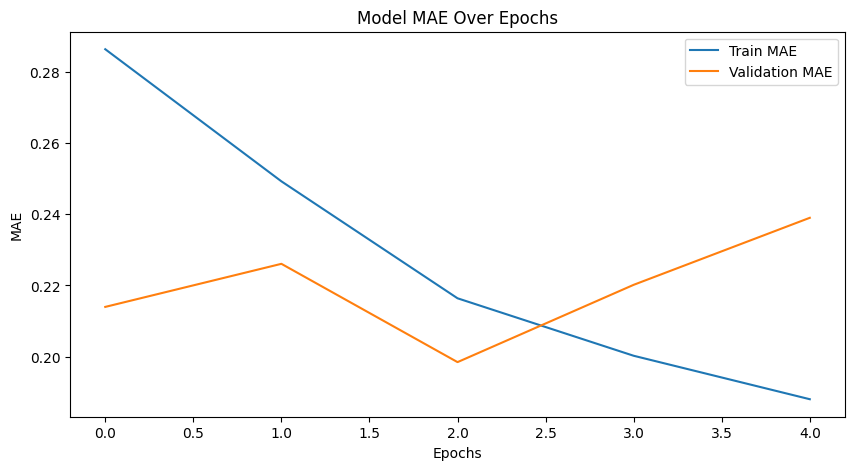

In [30]:
plt.figure(figsize=(10,5))

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title('Model MAE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.show()

In [31]:
def inverse_price(pred):
    temp = np.zeros((len(pred), len(features)))
    temp[:, target_idx] = pred[:, 0]
    return scaler.inverse_transform(temp)[:, target_idx]

y_test_real = inverse_price(y_test.reshape(-1, 1))
y_pred_real = inverse_price(y_pred)

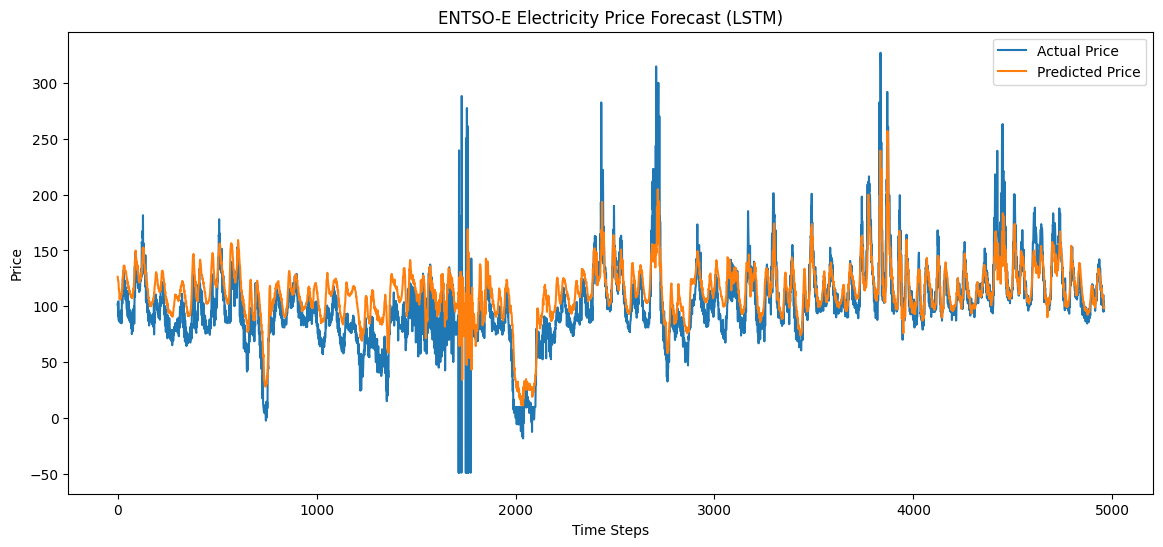

In [32]:
plt.figure(figsize=(14,6))

plt.plot(y_test_real, label="Actual Price")
plt.plot(y_pred_real, label="Predicted Price")

plt.title("ENTSO-E Electricity Price Forecast (LSTM)")
plt.xlabel("Time Steps")
plt.ylabel("Price")
plt.legend()

plt.show()

In [33]:
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 16.9241626134351
RMSE: 22.915654205997193


# Random Search